In [2]:
from utils.paths import SAMPLING_DIR, RAW_DIR,PREDICTIONS_DIR,PLOTS_DIR,DATABASE_DIR

In [3]:
import numpy as np
import pandas as pd
import pickle

from preprocessing.database_manager import DatabaseManager
from models_scripts.AdaptiveTransferKernel import AdaptiveTransferKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader
from preprocessing.DataPreprocessor import DataPreprocessor, DataSplitter
from preprocessing.Physics import DrudeAlloyModel
from preprocessing.TernaryPlot import plot_ternary_heatmap

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [5]:
#========= Experimental compositions ================
db = DatabaseManager(DATABASE_DIR/"Ternary_round1.db")

df_optical = db.table_dataframe('Optical_properties')
df_comp = db.table_dataframe('compositions')
db.close()

df_merged = df_optical.merge(df_comp, on="ID", how="inner")
tern_1550 = df_merged[np.isclose(df_merged["wavelength_nm"].astype(float), 1552.0)]

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [6]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)
dp = DataPreprocessor()


In [7]:
X = tern_1550[['Cu','Ni','Al']].copy()
y = tern_1550['e2'].copy()

In [37]:
splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="random"
)

random_split = splitter.split_training(X, y)

splitter = DataSplitter(
    test_size=0.05,
    random_state=42,
    split_method="cluster",
    n_clusters =6,
    cluster_feature_start= 0
)

cluster_split = splitter.split_training(X, y)

In [9]:
feature_cols = ['Cu','Ni','Al','r','del_r','del_EN','S','VEC']

x_train_rd, x_test_rd, y_train_rd, y_test_rd,scaler_rd = dp.train_test(
    random_split,
    calc,
    feature_cols,
    scaler = None
)

x_train_cl, x_test_cl, y_train_cl, y_test_cl,scaler_cl = dp.train_test(
    cluster_split,
    calc,
    feature_cols,
    scaler = None
)

Experimental data GP - Random splitting

In [10]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
)

gpr_nt_ran = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_ran.fit(x_train_rd, y_train_rd)
print("Learned kernel:", gpr_nt_ran.kernel_)

Learned kernel: 1.01**2 * Matern(length_scale=1.46, nu=2.5) + WhiteKernel(noise_level=0.269)


In [11]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_rd, error_rd = dp.gp_predict_and_errors(calc,x_all,gpr_nt_ran,scaler_rd,x_test_rd,y_test_rd,feature_cols)

df1 = random_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_rd['df_residuals'].reset_index(drop=True)
df_test_rd = pd.concat([df1,df2], axis=1)

Plots [Predicted plot and erro plot]

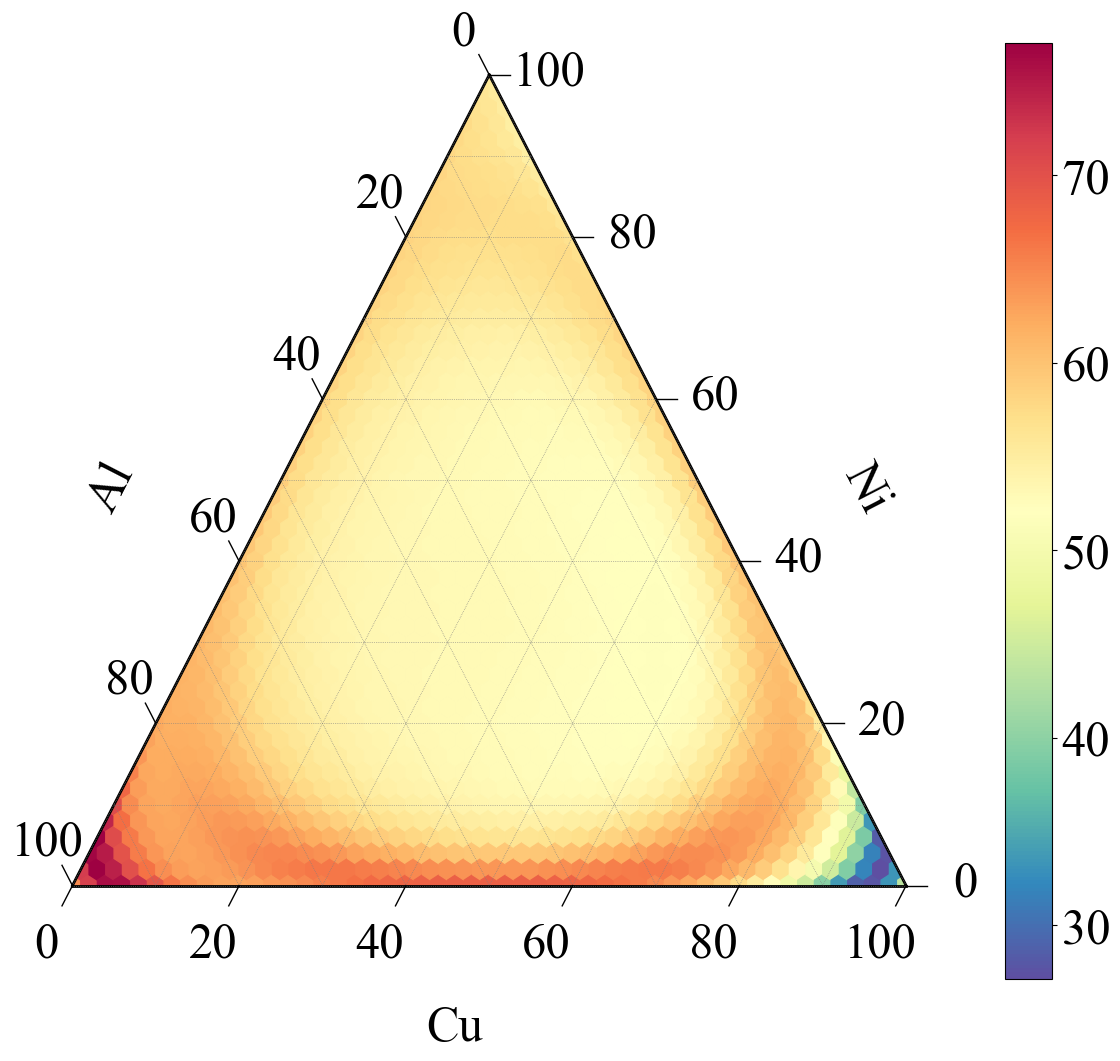

In [12]:
df_pred_rd[comp_cols] = df_pred_rd[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_PG_Random_split.svg", bbox_inches="tight")

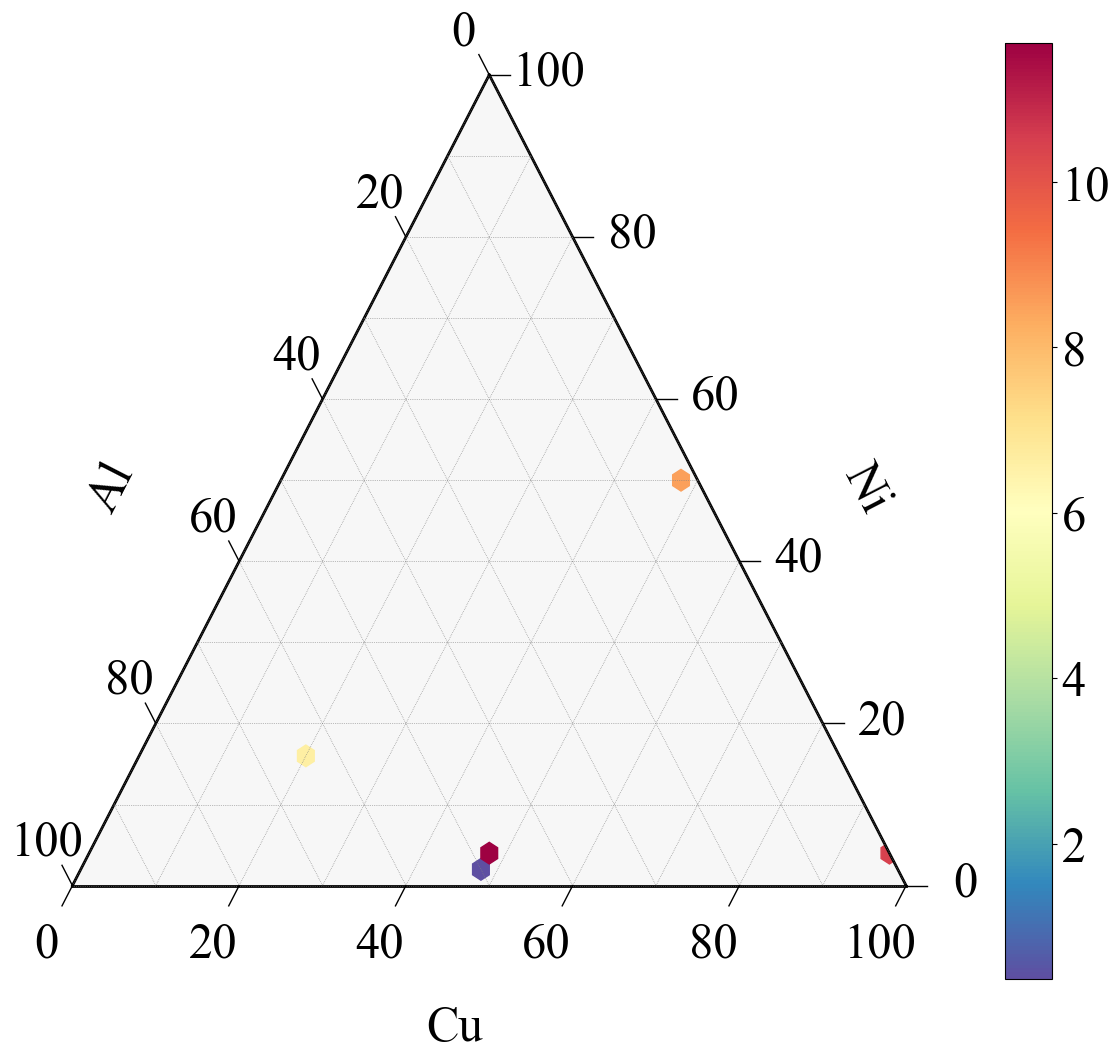

In [13]:
fig, tax = plot_ternary_heatmap(
    df=df_test_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_GP_error_rand_split.svg", bbox_inches="tight")


Experimental data GP - Kmeans splitting

In [14]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gpr_nt_clus = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_clus.fit(x_train_cl, y_train_cl)
print("Learned kernel:", gpr_nt_clus.kernel_)

Learned kernel: 0.922**2 * Matern(length_scale=1.31, nu=2.5) + WhiteKernel(noise_level=0.337)


In [15]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_cl, error_cl = dp.gp_predict_and_errors(calc,x_all,gpr_nt_clus,scaler_cl,x_test_cl,y_test_cl,feature_cols)

df1 = cluster_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_cl['df_residuals'].reset_index(drop=True)
df_test_cl = pd.concat([df1,df2], axis=1)

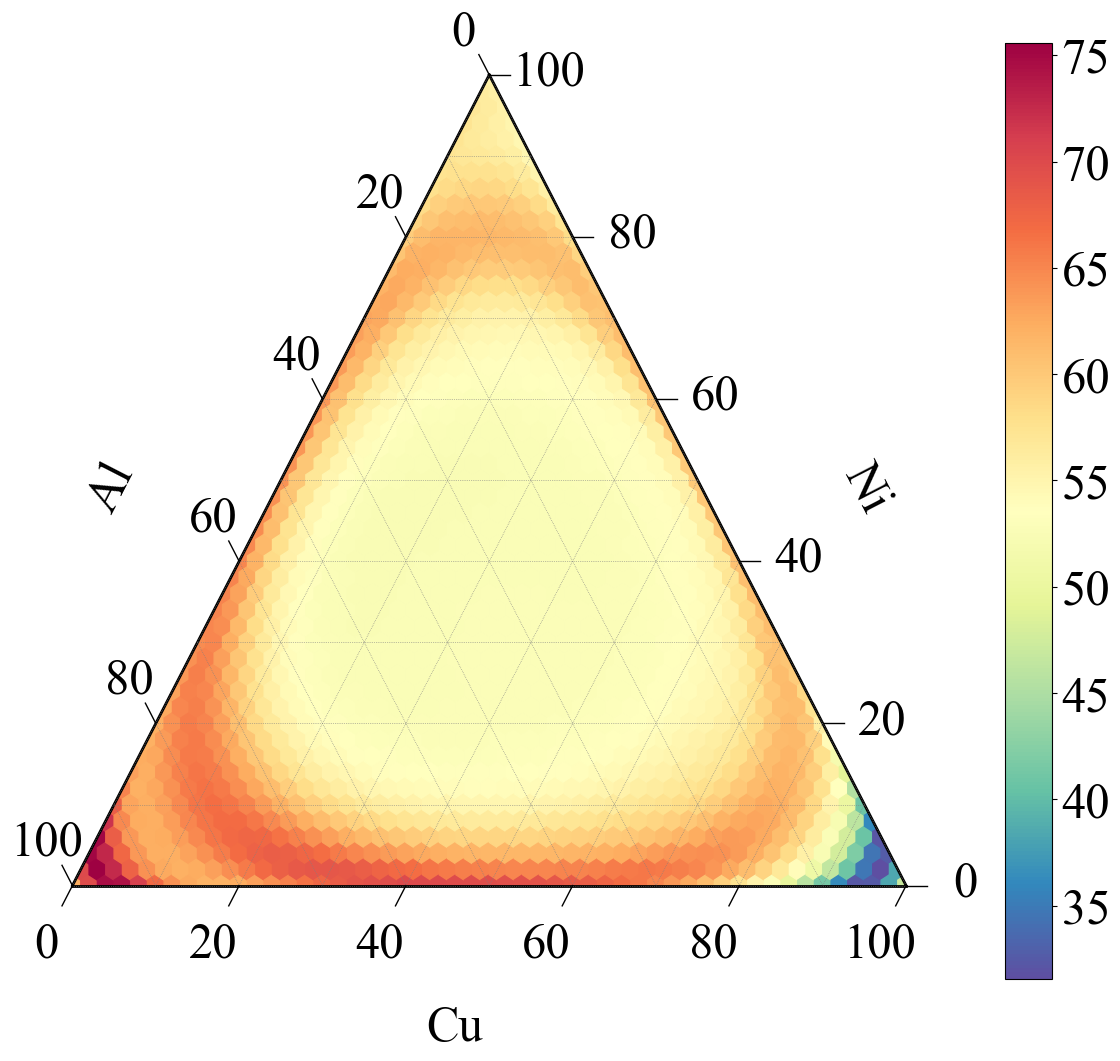

In [16]:
df_pred_cl[comp_cols] = df_pred_cl[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split.svg", bbox_inches="tight")

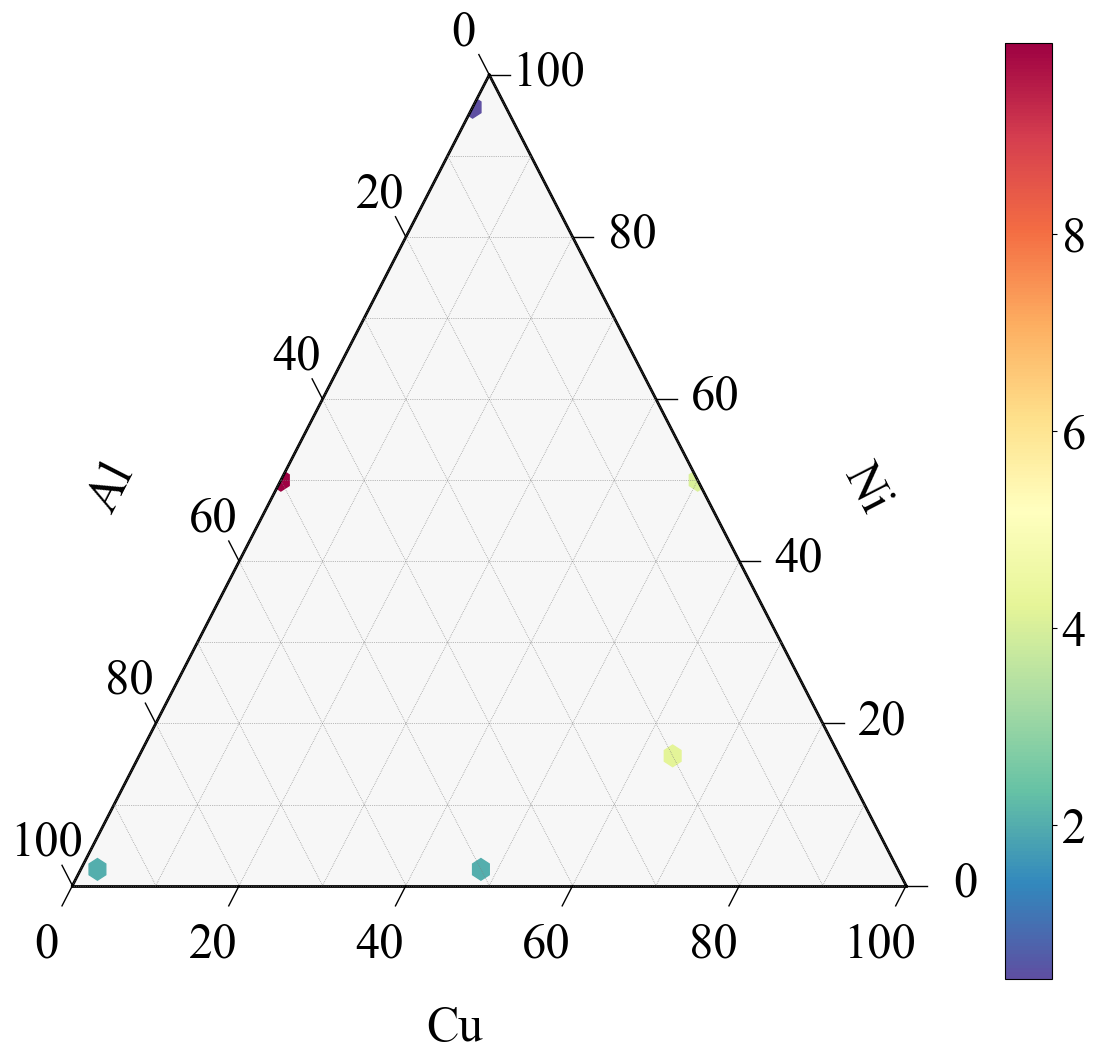

In [17]:
fig, tax = plot_ternary_heatmap(
    df=df_test_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split_error.svg", bbox_inches="tight")

Gaussian Process Resistivity  variable addition

In [23]:
comp_cols = ['Cu','Ni','Al']

experimental_space = pd.read_pickle(PREDICTIONS_DIR/"ANN_Predictions/experimental_resis_prediction.pkl")
experimental_space['resistivity'] = experimental_space['resistivity'] *1e-8
exp_resis_prediction = experimental_space[['Cu','Ni','Al','resistivity']]

In [39]:
cluster_split['X_train_split'] = cluster_split['X_train_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')
cluster_split['X_test_split'] = cluster_split['X_test_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')

In [40]:
feature_cols = ['Cu','Ni','Al','r','del_r','del_EN','S','VEC','resistivity']
x_train_cl, x_test_cl, y_train_cl, y_test_cl,scaler_cl = dp.train_test(
    cluster_split,
    calc,
    feature_cols,
    scaler = None
)

In [42]:
# Fit GP on residuals
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gp_resistivity = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)
gp_resistivity.fit(x_train_cl, y_train_cl)
print("Learned kernel:", gp_resistivity.kernel_)

Learned kernel: 0.922**2 * Matern(length_scale=1.31, nu=2.5) + WhiteKernel(noise_level=0.337)


In [43]:
y_resis_pred, y_resis_std = gp_resistivity.predict(x_test_cl, return_std=True)

In [46]:
## Error calculation
# Metrics
mse_res = mean_squared_error(cluster_split['y_test'], y_resis_pred)
rmse_res = np.sqrt(mse_res)
r2_res = r2_score(cluster_split['y_test'], y_resis_pred)

print("Residual GP Performance:")
print(f"MSE:  {mse_res:.4f}")
print(f"RMSE: {rmse_res:.4f}")
print(f"R2:   {r2_res}")

Residual GP Performance:
MSE:  23.4519
RMSE: 4.8427
R2:   0.66994812052278


Gaussina Process Residual Approach

In [50]:
experimental_space = pd.read_pickle(PREDICTIONS_DIR/"ANN_Predictions/experimental_resis_prediction.pkl")
experimental_space['resistivity'] = experimental_space['resistivity'] *1e-8
exp_resis_prediction = experimental_space[['Cu','Ni','Al','resistivity']]

comp_cols = ['Cu','Ni','Al']
X_physics_train = cluster_split['X_train_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')

In [ ]:
# Drude model class for e2 calculation
elem_cols = ["Cu","Al","Ni"]
ne_pure = [8.47e28,18.1e28,5.64e28]
drude = DrudeAlloyModel(elem_cols=elem_cols,ne_pure=ne_pure,wavelength_unit='nm')

df_physics_train = drude.predict_dataframe(df =X_physics_train,rho_col='resistivity',wvl=1550)

In [ ]:
#. Residuals
y_phys_train = np.asarray(df_physics_train['e2_drude'])
y_res_train = cluster_split['y_train'] - y_phys_train

In [65]:
# Fit GP on residuals
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gp_res = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)
gp_res.fit(x_train_cl, y_res_train)
print("Learned kernel:", gp_res.kernel_)

Learned kernel: 1.01**2 * Matern(length_scale=1.45, nu=2.5) + WhiteKernel(noise_level=0.303)


In [72]:
X_phys_test = cluster_split['X_test_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')
df_physics_test = drude.predict_dataframe(df =X_phys_test,rho_col='resistivity',wvl=1550)

y_phys_test = np.asarray(df_physics_test['e2_drude'])

In [82]:
# Predict on new points
y_res_pred, y_res_std = gp_res.predict(x_test_cl, return_std=True)

# Final Prediction
y_predic = y_phys_test + y_res_pred

In [85]:
error_cl

{'mae': 3.7664437287334955,
 'rmse': 4.842719933918951,
 'r2': 0.6699479449662948,
 'df_residuals':       y_true     y_pred     error  error_abs   error_sq
 0  55.827915  59.865334 -4.037419   4.037419  16.300753
 1  54.283161  64.217076 -9.933915   9.933915  98.682667
 2  50.837952  55.021145 -4.183193   4.183193  17.499101
 3  62.303177  64.312865 -2.009688   2.009688   4.038845
 4  56.649986  57.083952 -0.433966   0.433966   0.188327
 5  76.665421  74.664940  2.000481   2.000481   4.001926}

In [83]:
y_predic

array([51.5056446 , 64.52029065, 60.29462597, 64.55515143, 46.47692946,
       82.54243983])

In [77]:
## Error calculation
# Metrics
mse_res = mean_squared_error(cluster_split['y_test'], y_predic)
rmse_res = np.sqrt(mse_res)
r2_res = r2_score(cluster_split['y_test'], y_predic)

print("Residual GP Performance:")
print(f"MSE:  {mse_res:.4f}")
print(f"RMSE: {rmse_res:.4f}")
print(f"R2:   {r2_res:.4f}")

Residual GP Performance:
MSE:  59.3352
RMSE: 7.7029
R2:   0.1649


GPy module installation

In [ ]:
import GPy
# Mean function
mf = GPy.core.Mapping (input_dim=1, output_dim=1)
mf.f = lambda X: np.sin(X)
mf.update_gradients = lambda dL_dF, X:None

# Kernel
k = GPy.kern.RBF(input_dim=1)

#GP model with custom mean
m =  GPy.models.GPRegression(X, Y, kernel=k, mean_function=mf)